# Laboratorio de repaso de Python e introducción a POO

**Desarrollo de Sistemas de Inteligencia Artificial**

## Objetivos

Al finalizar el laboratorio se espera que puedan:

- utilizar condicionales considerando los valores *truthy* y *falsy*;
- construir repeticiones con `for`, `while` y `range()`;
- desempaquetar secuencias y valores retornados por funciones;
- definir funciones que retornen uno o varios resultados y reconocer funciones `lambda`;
- reconocer las formas habituales de importar módulos;
- crear y operar vectores y matrices con NumPy;
- explorar y visualizar datos con Pandas y Matplotlib;
- reconocer clases, objetos, constructores, atributos y métodos.

> Este laboratorio recupera contenidos previos. La programación orientada a objetos se introduce solamente en su nivel fundamental; otros conceptos se incorporarán cuando resulten necesarios durante la cursada.

# 1. Condicionales y valores *truthy* y *falsy*

Una condición permite decidir qué instrucciones deben ejecutarse. Python no exige que toda condición produzca explícitamente `True` o `False`: también puede interpretar la **veracidad** de un valor.

Los valores considerados falsos se denominan *falsy*. Entre los más habituales se encuentran:

- `False`;
- `None`;
- los números iguales a cero: `0`, `0.0`;
- las cadenas vacías: `""`;
- las colecciones vacías: `[]`, `{}`, `()`, `set()`.

En general, los demás valores son *truthy*.

In [48]:
valores = [False, None, 0, 0.0, "", [], {}, (), "0", "False", -5, [0]]

for valor in valores:
    print(repr(valor), '->', {bool(valor)})




False -> {False}
None -> {False}
0 -> {False}
0.0 -> {False}
'' -> {False}
[] -> {False}
{} -> {False}
() -> {False}
'0' -> {True}
'False' -> {True}
-5 -> {True}
[0] -> {True}


### Ejemplo completo de validación

`not nombre` resulta verdadero cuando `nombre` contiene una cadena vacía. Esto permite escribir validaciones breves, siempre que todos los valores *falsy* representen la misma situación para el problema.

In [49]:
nombre = "Marta"

edad_texto = "35"

if not nombre:
    mensaje = "Debe ingresar un nombre"

elif not edad_texto:
    mensaje = "Debe ingresar una edad"

elif not edad_texto.isdigit():
    mensaje = "La edad debe ser un numero entero"

else:
    edad = int(edad_texto)

    if edad >= 18:
        mensaje = f"{nombre} es mayor de edad."

    else:
        mensaje = f"{nombre} es menor de edad."

print(mensaje)

Marta es mayor de edad.


### `None` no siempre significa lo mismo que cero

El uso de `if not valor` no es apropiado cuando el programa debe diferenciar entre ausencia de información y un cero válido. En esos casos debe compararse explícitamente con `None` mediante `is None`.

In [50]:
cantidad = '0'

if cantidad:
    print("Se ingreso una cantidad")

cantidad = 0

if not cantidad:
    print("Parece que no se ingreso otra cantidad")

if cantidad is None:
    print("Efectivamente la cantidad no fue ingresada")

else:
    print(f"La cantidad ingresada es {cantidad}")

Se ingreso una cantidad
Parece que no se ingreso otra cantidad
La cantidad ingresada es 0


### Ejercicio 1 — Resuelto

Dado un valor que representa una lista de observaciones, informar si existen datos para procesar. Si existen, mostrar cuántas observaciones contiene.

In [51]:
observaciones = [18, 21, 25, 19]

if observaciones:
    print(f"Se procesaran {len(observaciones)} observaciones")

else:
    print("No existen observaciones para procesar")

Se procesaran 4 observaciones


# 2. Bucles y `range()`

- `for` se utiliza principalmente para recorrer los elementos de un iterable.
- `while` repite un bloque mientras una condición sea verdadera.
- `range(inicio, fin, paso)` genera una secuencia de enteros. El valor indicado como `fin` **no se incluye**.

In [52]:
print("range(5):")

for numero in range(5):
    print(numero, end=" ")

print("\n\nrange(2, 8, 2):")

for numero in range(2, 8, 2):

    print(numero, end=" ")


print("\n\nrange(5, 0, -1):")

for numero in range(5, 0, -1):

    print(numero, end=" ")

range(5):
0 1 2 3 4 

range(2, 8, 2):
2 4 6 

range(5, 0, -1):
5 4 3 2 1 

### Recorrido por índices y uso de `enumerate()`

`range(len(...))` permite recorrer índices. Sin embargo, si se necesitan simultáneamente el índice y el elemento, `enumerate()` suele expresar mejor la intención.

In [53]:
nombres = ["Ana", "Bruno", "Carla"]

for indice in range(len(nombres)):

    print(indice, nombres[indice])

print()

for indice, nombre in enumerate(nombres, start=1):
    print(f"{indice}. {nombre}")

0 Ana
1 Bruno
2 Carla

1. Ana
2. Bruno
3. Carla


In [54]:

clave_correcta = "python"

intentos = ["java", "javascript", "typescript", "python", "c#"]

posicion = 0

clave = ""


while clave != clave_correcta and posicion < len(intentos):

    clave = intentos[posicion]

    print(f"Intento { posicion + 1}: {clave}")

    posicion += 1

if clave == clave_correcta:

    print("Acceso permitido")

else:
    print("Cantidad de intentos agotada")



nombre = input("ingrese un nombre")
contador = 0
# Si el nombre ingresado no es marta, me vuelva a pedir que ingrese el nombre, hasta 3 veces

while nombre != "marta" and nombre != "Marta" and contador < 2:   # julian
    print("Nombre incorrecto")
    nombre = input("Ingrese otro nombre")
    contador = contador + 1

if nombre == "Marta" or nombre == "marta":
    print("El nombre es correcto!")
else:
    print("Adivinar no es lo tuyo")

Intento 1: java
Intento 2: javascript
Intento 3: typescript
Intento 4: python
Acceso permitido
Nombre incorrecto
Nombre incorrecto
Adivinar no es lo tuyo


### Ejercicio 2 — Resuelto

Mostrar la tabla de multiplicar del 7, desde `7 × 1` hasta `7 × 10`.

In [55]:
numero = 7

for multiplicador in range(1,11):
    resultado = numero * multiplicador
    print(f"{numero} x {multiplicador} = {resultado}")

7 x 1 = 7
7 x 2 = 14
7 x 3 = 21
7 x 4 = 28
7 x 5 = 35
7 x 6 = 42
7 x 7 = 49
7 x 8 = 56
7 x 9 = 63
7 x 10 = 70


# 3. Desempaquetado y funciones

En Python, el **desempaquetado** permite asignar los elementos de una secuencia a distintas variables en una única instrucción.

In [56]:
persona = ("Ana", 25, "Datos e IA")

nombre, edad, area = persona

print(nombre)

print(edad)

print(area)


Ana
25
Datos e IA


In [57]:
numeros = [10, 20, 30, 40, 50]


primero, segundo, *restantes = numeros

print(primero)
print(segundo)
print(restantes)

print(numeros)

# treinta =  numeros.pop(2)
# 
# print(treinta)
# 
# print(numeros)

10
20
[30, 40, 50]
[10, 20, 30, 40, 50]


### Funciones y `return`

Una función agrupa instrucciones que cumplen una tarea. Los parámetros reciben los datos de entrada y `return` entrega el resultado al código que llamó a la función.

Cuando los valores se separan mediante comas en `return`, Python construye y devuelve una **tupla**.

In [58]:
def calcular_estadisticas(numeros):
    minimo = min(numeros)

    maximo = max(numeros)

    promedio = sum(numeros) / len(numeros)

    return minimo, maximo, promedio 

# resultado = calcular_estadisticas([6,5,10,7])
calcular_estadisticas([6,5,10,7])
# print(resultado)
# print(type(resultado))

(5, 10, 7.0)

In [59]:
minimo, maximo, resultado = calcular_estadisticas([6,5,10,7])

print(minimo)
print(maximo)
print(resultado)

5
10
7.0


### Ejercicio 3 — Resuelto

Crear una función que reciba una lista de calificaciones y retorne la cantidad de aprobadas y desaprobadas. Se considera aprobada una calificación igual o superior a 6.

In [60]:
def contar_resultados(calificaciones, nota_minima=6):
    aprobadas = 0

    desaprobadas = 0

    for calificacion in calificaciones:

        if calificacion >= nota_minima:
            aprobadas += 1
        else:
            desaprobadas += 1

    return aprobadas, desaprobadas


aprobadas, desaprobadas = contar_resultados([8, 4, 7, 9, 3, 6])

print("Aprobadas:", aprobadas)
print("Desaprobadas:", desaprobadas)

Aprobadas: 4
Desaprobadas: 2


## Funciones `lambda`

Una función `lambda` es una función anónima y breve formada por una única expresión. Su sintaxis general es:

```python
lambda parametros: expresion
```

No se escribe `return`: el resultado de la expresión se retorna automáticamente. Resulta útil cuando otra función necesita recibir un comportamiento sencillo, por ejemplo mediante el parámetro `key` de `sorted()`.

> Una función `lambda` no reemplaza a todas las funciones definidas con `def`. Si la operación requiere varias instrucciones, validaciones, documentación o reutilización frecuente, debe utilizarse `def`.

In [61]:
def calcular_cuadrado(numero):
    return numero ** 2

cuadrado = calcular_cuadrado(5)

print(cuadrado)

cuadrado_lambda = lambda numero: numero ** 2

print(cuadrado_lambda(5))
print(cuadrado_lambda(2))
print(cuadrado_lambda(8))


25
25
4
64


### Uso de `lambda` como argumento

En el siguiente ejemplo, `sorted()` recibe una función mediante `key`. Para cada tupla, la función `lambda` retorna el segundo elemento, que será utilizado como criterio de ordenamiento.

In [62]:
estudiantes = [
    ("Ana", 8),
    ("Bruno", 6),
    ("Carla", 9)
]

estudiantes_ordendos = sorted(
    estudiantes,
    key = lambda cada_estudiante: cada_estudiante[1],
    reverse=True
)

print(estudiantes_ordendos)
print(estudiantes)



[('Carla', 9), ('Ana', 8), ('Bruno', 6)]
[('Ana', 8), ('Bruno', 6), ('Carla', 9)]


`sorted()` y `sort()` no son lo mismo

| Característica                  | `sorted()`                                                                        | `.sort()`                                        |
| ------------------------------- | --------------------------------------------------------------------------------- | ------------------------------------------------ |
| Tipo                            | Función incorporada de Python                                                     | Método de las listas                             |
| Forma de uso                    | `sorted(coleccion)`                                                               | `lista.sort()`                                   |
| Estructuras admitidas           | Cualquier iterable: listas, tuplas, conjuntos, diccionarios, etc.                 | Solamente listas                                 |
| Modifica la estructura original | No                                                                                | Sí                                               |
| Resultado                       | Devuelve una lista nueva ordenada                                                 | Devuelve `None`                                  |
| Conserva la colección original  | Sí                                                                                | No                                               |
| Orden descendente               | `sorted(coleccion, reverse=True)`                                                 | `lista.sort(reverse=True)`                       |
| Criterio personalizado          | `sorted(coleccion, key=funcion)`                                                  | `lista.sort(key=funcion)`                        |
| Uso recomendado                 | Cuando se necesita conservar la colección original o se trabaja con otro iterable | Cuando se desea modificar directamente una lista |


### `lambda` con `map()` y `filter()`

`map()` transforma cada elemento y `filter()` conserva los elementos que cumplen una condición. Ambos retornan iteradores, por eso se convierten en listas para visualizar sus resultados. En muchos casos, una comprensión de listas constituye una alternativa más legible.

In [63]:
numeros = [1, 2, 3, 4, 5]

cuadrados = list(map(lambda numero: numero**2, numeros))
print(cuadrados)

pares = list(filter(lambda numero: numero % 2 == 0, numeros))

print(pares)

[1, 4, 9, 16, 25]
[2, 4]


# 4. Importación de módulos

Las importaciones permiten utilizar código definido en módulos y bibliotecas.

```python
import modulo
from modulo import elemento
import modulo as alias
```

Los alias `np`, `pd` y `plt` son convenciones ampliamente utilizadas; no son palabras reservadas de Python.

In [64]:
# Importa el módulo completo para acceder a sus elementos mediante su nombre o alias.
import math

# Importa elementos específicos desde el módulo indicado.
from statistics import mean

# Importa el módulo completo para acceder a sus elementos mediante su nombre o alias.
import numpy as np

# Importa el módulo completo para acceder a sus elementos mediante su nombre o alias.
import pandas as pd

# Importa el módulo completo para acceder a sus elementos mediante su nombre o alias.
import matplotlib.pyplot as plt

print("Raiz cuadrada:", math.sqrt(25))

print("Promedio:", mean([4, 6, 8]))

Raiz cuadrada: 5.0
Promedio: 6


| Concepto | Definición | Ejemplo | Forma de uso |
|---|---|---|---|
| Script | Archivo de Python pensado principalmente para ejecutarse directamente. | `programa.py` | `python programa.py` |
| Módulo | Archivo o componente importable que contiene variables, funciones o clases reutilizables. Un archivo `.py` puede funcionar como módulo. | `math`, `statistics`, `utilidades.py` | `import math` |
| Paquete | Estructura que agrupa módulos y, posiblemente, otros subpaquetes bajo un mismo nombre. Habitualmente corresponde a una carpeta. | `matplotlib`, `sklearn.model_selection` | `from sklearn import model_selection` |
| Biblioteca | Conjunto de funcionalidades reutilizables. Puede estar formada por uno o varios paquetes y módulos. Es un concepto más general que una estructura concreta de Python. | NumPy, Pandas, Matplotlib | `import pandas as pd` |
| Biblioteca estándar | Conjunto de módulos y paquetes incluidos con Python, por lo que no requieren una instalación adicional. | `math`, `statistics`, `pathlib`, `urllib` | `from pathlib import Path` |
| Biblioteca externa | Biblioteca desarrollada fuera de la distribución estándar de Python. Debe instalarse antes de importarse. | NumPy, Pandas, Matplotlib | `pip install pandas` |
| Framework | Conjunto estructurado de herramientas que define una forma de construir aplicaciones y suele controlar parte del flujo de ejecución. | Django, Flask, FastAPI | Depende del framework |

Un mismo recurso puede describirse en distintos niveles. Por ejemplo, Matplotlib es una biblioteca; dentro de ella existe el paquete matplotlib y dentro de este se encuentra el módulo pyplot.

Se recomienda evitar `from modulo import *`, porque incorpora numerosos nombres al espacio actual y dificulta identificar su origen.

## Listas de Python y arrays de NumPy

Antes de trabajar con NumPy conviene distinguir ambas estructuras. Aunque las dos almacenan varios valores y utilizan índices, no tienen el mismo propósito.

| Característica | Lista de Python | Array de NumPy |
|---|---|---|
| Creación | `[1, 2, 3]` | `np.array([1, 2, 3])` |
| Tipos de datos | Puede mezclar tipos libremente | Normalmente utiliza un único tipo común (`dtype`) |
| Operaciones matemáticas | Requiere recorridos o comprensiones | Permite operaciones vectorizadas |
| Dimensiones | Puede anidar listas, pero no posee `shape` | Gestiona dimensiones y forma mediante `ndim` y `shape` |
| Tamaño | Se amplía fácilmente con `append()` | Su tamaño es fijo; las modificaciones suelen crear otro array |
| Uso habitual | Colecciones generales | Cálculo numérico, matrices y ciencia de datos |

La diferencia se observa claramente al utilizar el operador `*`: en una lista repite sus elementos; en un array multiplica cada elemento.

In [65]:
lista = [1, 2, 3]

array = np.array([1, 2, 3])

print("Lista * 2", lista * 2)
print("Array * 2", array * 2)

Lista * 2 [1, 2, 3, 1, 2, 3]
Array * 2 [2 4 6]


# 5. NumPy: vectores y matrices

NumPy trabaja principalmente con objetos `ndarray`. Un array de una dimensión puede interpretarse como un vector y uno de dos dimensiones como una matriz.

> Aunque existe `np.matrix`, no se utilizará: para el trabajo habitual se prefieren arrays `ndarray` bidimensionales.

In [66]:
vector = np.array([8, 4, 7, 9, 6])

lista = [8, 4, 7, 9, 6]

print(vector)

print("Dimensiones:", vector.ndim)

print("Forma:", vector.shape)

print("Cantidad de elementos:", len(vector))
print("Cantidad de elementos:", vector.size)
print("Cantidad de elementos:", len(lista))
# print("Cantidad de elementos:", lista.size)



[8 4 7 9 6]
Dimensiones: 1
Forma: (5,)
Cantidad de elementos: 5
Cantidad de elementos: 5
Cantidad de elementos: 5


In [67]:
calificaciones = np.array([
    [8, 7, 9],
    [6, 5, 7],
    [10, 9, 8],
    [4, 6, 5]
])

print(calificaciones)

print("Dimensiones:", calificaciones.ndim)

print("Forma:", calificaciones.shape )



[[ 8  7  9]
 [ 6  5  7]
 [10  9  8]
 [ 4  6  5]]
Dimensiones: 2
Forma: (4, 3)


### Acceso a elementos, filas y columnas

En una matriz se indican primero la fila y luego la columna. Los índices comienzan en cero.

In [68]:
# Fila 1 y columna 1

print("Fila 1, columna 1:", calificaciones[0][0])
print("Fila 1, columna 1:", calificaciones[0, 0])

print("Fila 3, columna 2:", calificaciones[2, 1])

primera_fila = calificaciones[0, :]
segunda_columna = calificaciones[:, 1]

print("Primera fila", primera_fila)
print("Segunda fila", segunda_columna)

Fila 1, columna 1: 8
Fila 1, columna 1: 8
Fila 3, columna 2: 9
Primera fila [8 7 9]
Segunda fila [7 5 9 6]


### Operaciones por eje

- `axis=0` reduce las filas y produce un resultado por columna.
- `axis=1` reduce las columnas y produce un resultado por fila.

In [69]:
# [[ 8  7  9]
#  [ 6  5  7]
#  [10  9  8]
#  [ 4  6  5]]

promedio_general = calificaciones.mean()

print("Promedio general:", promedio_general)

promedio_por_estudiante = calificaciones.mean(axis=1)

print("Promedio por estudiante:", promedio_por_estudiante)

promedio_por_evaluacion = calificaciones.mean(axis=0)

print("Promedio por evaluacion:", promedio_por_evaluacion)

Promedio general: 7.0
Promedio por estudiante: [8. 6. 9. 5.]
Promedio por evaluacion: [7.   6.75 7.25]


### Comparaciones vectorizadas

Una comparación aplicada a un array genera otro array de valores booleanos. Para formular una única condición pueden emplearse `.any()` o `.all()`.

In [70]:
# [[ 8  7  9]
#  [ 6  5  7]
#  [10  9  8]
#  [ 4  6  5]]

mascara_aprobadas = calificaciones >= 6

print(mascara_aprobadas)

print("Cantidad de notas aprobadas:", mascara_aprobadas.sum())

print("Existe algun 10?", (calificaciones == 10).any())

print("Todas las notas son aprobadas?", (calificaciones >= 6).all())

[[ True  True  True]
 [ True False  True]
 [ True  True  True]
 [False  True False]]
Cantidad de notas aprobadas: 9
Existe algun 10? True
Todas las notas son aprobadas? False


No debe escribirse `if calificaciones:` cuando el array contiene varios elementos. NumPy no puede decidir si se pretende comprobar todos los valores o al menos uno. Para comprobar si existen elementos puede utilizarse `calificaciones.size > 0`.

In [71]:
if calificaciones.size > 0:
    print("La matriz contiene datos")

if(calificaciones == 10).any():
    print("Al menos una calificacion es igual a 10")

if(calificaciones == 3).any():
    print("Al menos una calificacion es igual a 10")

La matriz contiene datos
Al menos una calificacion es igual a 10


### Ejercicio 4 — Resuelto

Obtener los promedios por estudiante e informar qué números de estudiante alcanzaron un promedio igual o superior a 6.

In [72]:
# calificaciones = np.array([
#     [8, 7, 9],
#     [6, 5, 7],
#     [10, 9, 8],
#     [4, 6, 5]
# ])

promedios = calificaciones.mean(axis=1)
condicion_aprobados = promedios >= 6
indices_aprobados = np.where(condicion_aprobados)[0]
numeros_estudiantes = indices_aprobados + 1

print("Promedios:", promedios)
print("condicion aprobados:", condicion_aprobados)
print("Indices aprobados:", indices_aprobados)
print("Estudiantes aprobados:", numeros_estudiantes)

Promedios: [8. 6. 9. 5.]
condicion aprobados: [ True  True  True False]
Indices aprobados: [0 1 2]
Estudiantes aprobados: [1 2 3]


# 6. Pandas y Matplotlib: dataset Titanic

Se utilizará la versión del dataset Titanic publicada en el repositorio de datos de Seaborn.

- [Descargar `titanic.csv`](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv)
- [Ver el archivo en GitHub](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv)

La siguiente celda crea la carpeta `data` si no existe y descarga allí el archivo. Si `data/titanic.csv` ya existe, no vuelve a descargarlo.

## Corchetes y paréntesis en diccionarios y DataFrames

Los símbolos no son intercambiables: representan operaciones distintas.

| Escritura | Significado |
|---|---|
| `diccionario["clave"]` | Accede al valor asociado con una clave. Produce `KeyError` si la clave no existe. |
| `diccionario.get("clave")` | Llama al método `get()`. Permite obtener `None` o un valor predeterminado si la clave no existe. |
| `df["columna"]` | Selecciona una columna y devuelve una `Series`. |
| `df[["columna_1", "columna_2"]]` | Selecciona varias columnas y devuelve un `DataFrame`. |
| `df.loc[filas, columnas]` | Selecciona mediante etiquetas. `loc` es un indexador y por eso utiliza corchetes. |
| `df.iloc[filas, columnas]` | Selecciona mediante posiciones enteras. |
| `df.head()` | Llama al método `head`; los paréntesis ejecutan el método. |
| `df.groupby("pclass")` | Llama al método `groupby` y le pasa `"pclass"` como argumento. |

Por lo tanto, `df["age"].mean()` combina ambas operaciones: primero los corchetes seleccionan la columna `age` y después los paréntesis ejecutan su método `mean()`. Escribir `df("age")` sería incorrecto porque un DataFrame no es una función.

In [73]:
persona = {"nombre": "Ana", "edad": 25}


print(persona["nombre"])

print(persona.get("area", "Sin area informada"))

df_ejemplo = pd.DataFrame({
    "nombre": ["ana", "bruno"],
    "edad": [25, 31]
})

print(df_ejemplo)

edades = df_ejemplo["edad"]
print()

print(edades)

promedio_edades = edades.mean()

print()

print(promedio_edades)

Ana
Sin area informada
  nombre  edad
0    ana    25
1  bruno    31

0    25
1    31
Name: edad, dtype: int64

28.0


In [74]:
# Importa elementos específicos desde el módulo indicado.
from pathlib import Path
# Importa elementos específicos desde el módulo indicado.
from urllib.request import urlretrieve

# Evalúa la expresión de la derecha y guarda el resultado en `URL_TITANIC`.
URL_TITANIC = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
# Evalúa la expresión de la derecha y guarda el resultado en `ruta_titanic`.
ruta_titanic = Path("data/titanic.csv")

# Crea la carpeta `data`; también crea carpetas intermedias y no falla si ya existe.
ruta_titanic.parent.mkdir(parents=True, exist_ok=True)

# Evalúa la condición y ejecuta el bloque indentado únicamente cuando resulta verdadera.
if not ruta_titanic.exists():
    # Llama a la función o al método con los argumentos indicados.
    urlretrieve(URL_TITANIC, ruta_titanic)
    # Muestra en la salida el texto o los valores indicados.
    print(f"Archivo descargado en: {ruta_titanic}")
# Abre la alternativa que se ejecuta cuando las condiciones anteriores son falsas.
else:
    # Muestra en la salida el texto o los valores indicados.
    print(f"El archivo ya existe en: {ruta_titanic}")

El archivo ya existe en: data\titanic.csv


### Carga e inspección inicial

La versión utilizada contiene nombres de columnas en minúsculas, como `survived`, `pclass`, `sex`, `age` y `fare`.

In [75]:
df = pd.read_csv(ruta_titanic)

# print(df)

display(df.head())

print("Filas y columnas:", df.shape)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Filas y columnas: (891, 15)


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [77]:
columnas_interes = ["survived", "pclass", "sex","age","fare", "embark_town"]

display(df[columnas_interes])
display(df[columnas_interes].describe())
display(df[columnas_interes].describe(include="all"))

,survived,pclass,sex,age,fare,embark_town
0,0,3,male,22.0,7.2500,Southampton
1,1,1,female,38.0,71.2833,Cherbourg
2,1,3,female,26.0,7.9250,Southampton
3,1,1,female,35.0,53.1000,Southampton
4,0,3,male,35.0,8.0500,Southampton
...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,Southampton
887,1,1,female,19.0,30.0000,Southampton
888,0,3,female,NaN,23.4500,Southampton
889,1,1,male,26.0,30.0000,Cherbourg


,survived,pclass,age,fare
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208
std,0.486592,0.836071,14.526497,49.693429
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,7.910400
50%,0.000000,3.000000,28.000000,14.454200
75%,1.000000,3.000000,38.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


,survived,pclass,sex,age,fare,embark_town
count,891.000000,891.000000,891,714.000000,891.000000,889
unique,NaN,NaN,2,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,Southampton
freq,NaN,NaN,577,NaN,NaN,644
mean,0.383838,2.308642,NaN,29.699118,32.204208,NaN
std,0.486592,0.836071,NaN,14.526497,49.693429,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,NaN
25%,0.000000,2.000000,NaN,20.125000,7.910400,NaN
50%,0.000000,3.000000,NaN,28.000000,14.454200,NaN
75%,1.000000,3.000000,NaN,38.000000,31.000000,NaN


### Supervivencia general

Como `survived` utiliza `0` para indicar que la persona no sobrevivió y `1` para indicar que sí sobrevivió, su promedio representa la proporción de supervivencia.

In [78]:
proporcion_supervivencia = df["survived"].mean()

print("Proporcion de supervivencia:", proporcion_supervivencia)

print(f"Propocion supervivencia con amor: {proporcion_supervivencia:.2%}") 

Proporcion de supervivencia: 0.3838383838383838
Propocion supervivencia con amor: 38.38%


### Agrupamiento por clase

`groupby()` agrupa las filas según una variable. Luego se calcula el promedio de `survived` dentro de cada grupo.

In [79]:
supervivencia_por_clase = (
    df.groupby("pclass")["survived"].mean()
)

display(supervivencia_por_clase)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

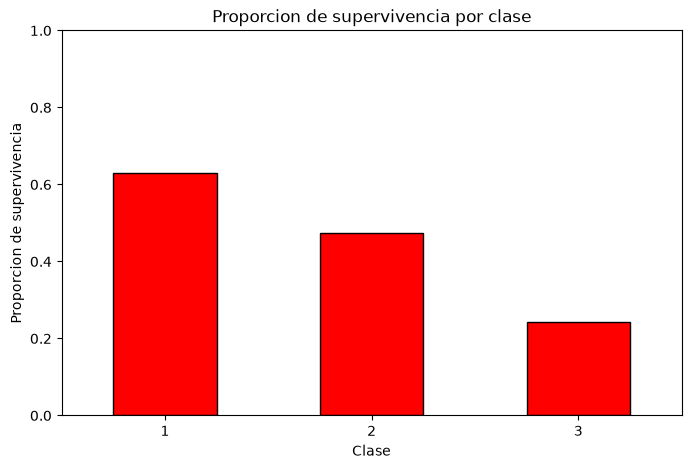

In [80]:
grafico = supervivencia_por_clase.plot(
    kind= "bar",
    color = "red",
    edgecolor= "black",
    figsize=(8,5)
)

grafico.set_title("Proporcion de supervivencia por clase")
grafico.set_xlabel("Clase")
grafico.set_ylabel("Proporcion de supervivencia")
grafico.set_ylim(0,1)
grafico.tick_params(axis="x", rotation=0)


plt.show()

### Ejercicio 5 — Resuelto

Calcular y representar la proporción de supervivencia según sexo.

sex
male      0.188908
female    0.742038
Name: survived, dtype: float64

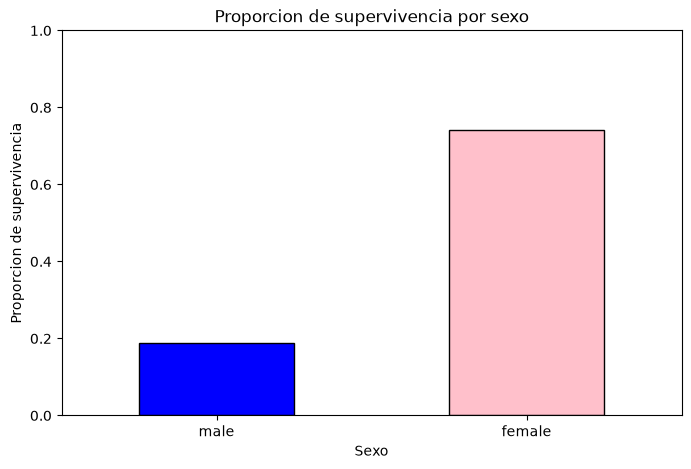

In [81]:
supervivncia_por_sexo = (
    df.groupby("sex")["survived"]
    .mean()
    .sort_values()
)

display(supervivncia_por_sexo)

graf = supervivncia_por_sexo.plot(
    kind="bar",
    color = ["blue", "pink"],
    edgecolor="black",
    figsize=(8,5)
)

graf.set_title("Proporcion de supervivencia por sexo")
graf.set_xlabel("Sexo")
graf.set_ylabel("Proporcion de supervivencia")
graf.set_ylim(0,1)
graf.tick_params(axis="x", rotation=0)

plt.show()

### Ejercicio 6 — Resuelto

Crear grupos etarios y comparar la proporción de supervivencia. Las edades ausentes permanecen como valores nulos y no se incluyen en los grupos.

## Práctica adicional con Titanic

Resolver los ejercicios 7 al 16 con el DataFrame `df` cargado desde `data/titanic.csv` y las bibliotecas ya importadas (`pd`, `np` y `plt`). Cada ejercicio incluye una celda para desarrollar la solución. Cuando se agreguen columnas o completen datos, trabajar sobre una copia para conservar el dataset original.

### Ejercicio 7 — Selección y filtros combinados

1. Seleccionar las personas de tercera clase (`pclass == 3`) con edad conocida menor a 18 años.
2. Mostrar solamente `sex`, `age`, `fare` y `survived`, ordenadas por edad de menor a mayor.
3. Informar cuántas personas cumplen las condiciones y qué porcentaje representan sobre el total del dataset.

**Pista:** combinar condiciones con `&` y encerrar cada condición entre paréntesis; usar `.loc` y `.sort_values()`.

In [82]:
# Ejercicio 7
# filtro los pasajeros de tercera clase que tienen edad informada y son menores de 18
# muestro solo las columnas que pide la consigna, ordeno por edad y calculo la cantidad y el porcentaje

filtro = (df["pclass"] == 3) & (df["age"].notna()) & (df["age"] < 18)

resultado = df.loc[filtro, ["sex", "age", "fare", "survived"]]
resultado = resultado.sort_values("age")

display(resultado)

print("Cantidad:", len(resultado))
print("Porcentaje:", len(resultado) / len(df) * 100)

,sex,age,fare,survived
803,male,0.42,8.5167,1
644,female,0.75,19.2583,1
469,female,0.75,19.2583,1
172,female,1.00,11.1333,1
381,female,1.00,15.7417,1
...,...,...,...,...
532,male,17.00,7.2292,0
500,male,17.00,8.6625,0
433,male,17.00,7.1250,0
114,female,17.00,14.4583,0


Cantidad: 78
Porcentaje: 8.754208754208754


### Ejercicio 8 — Diagnóstico de valores faltantes

1. Crear una tabla con la cantidad y el porcentaje de valores nulos de cada columna.
2. Mostrar únicamente las columnas con datos faltantes, ordenadas de mayor a menor porcentaje.
3. Crear una copia de `df` y completar las edades ausentes con la mediana de `age`.
4. Comparar el promedio de edad antes y después de completar los datos. Explicar por qué podría cambiar.

**Pista:** usar `.isna()`, `.sum()`, `.copy()` y `.fillna()`. Conservar `df` sin modificar para los demás ejercicios.

In [83]:

# Ejercicio 8

# veo cuantos datos faltan en cada columna
nulos = df.isna().sum()
porcentaje = nulos / len(df) * 100

tabla = pd.DataFrame({
    "cantidad": nulos,
    "porcentaje": porcentaje
})

# muestro solo las que tienen datos faltantes
tabla = tabla[tabla["cantidad"] > 0]
tabla = tabla.sort_values("porcentaje", ascending=False)

display(tabla)

# hago una copia para no modificar el df original
df_copia = df.copy()

promedio_antes = df["age"].mean()
mediana = df["age"].median()

df_copia["age"] = df_copia["age"].fillna(mediana)

promedio_despues = df_copia["age"].mean()

print("Promedio antes:", promedio_antes)
print("Promedio despues:", promedio_despues)

# puede cambiar porque los datos que faltaban se completaron con la mediana
# conté los datos faltantes y calculé el porcentaje
# luego hice una copia del DataFrame, completé las edades que faltaban con la mediana y comparé el promedio antes y después

,cantidad,porcentaje
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


Promedio antes: 29.69911764705882
Promedio despues: 29.36158249158249


### Ejercicio 9 — Tarifas y pasajeros destacados

1. Calcular el mínimo, el máximo, la media y la mediana de `fare`.
2. Mostrar las 10 filas con las tarifas más altas, incluyendo `pclass`, `sex`, `age`, `fare` y `embark_town`.
3. Contar cuántas personas tienen tarifa igual a cero.
4. Comparar la media con la mediana y explicar qué efecto podrían tener las tarifas muy altas.

**Pista:** usar `.describe()`, `.median()` y `.sort_values()` o `.nlargest()`.

In [84]:
# Ejercicio 9

# miro los datos principales de las tarifas
print(df["fare"].describe())
print("Mediana:", df["fare"].median())

# busco las 10 tarifas mas altas
tarifas_altas = df.nlargest(10, "fare")
display(tarifas_altas[["pclass", "sex", "age", "fare", "embark_town"]])

# cuento cuantos tienen tarifa 0
print("Tarifas en cero:", (df["fare"] == 0).sum())

# comparo la media con la mediana
print("Media:", df["fare"].mean())
print("Mediana:", df["fare"].median())

# las tarifas muy altas hacen subir la media
# la mediana no cambia tanto por esos valores

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64
Mediana: 14.4542


,pclass,sex,age,fare,embark_town
258,1,female,35.0,512.3292,Cherbourg
679,1,male,36.0,512.3292,Cherbourg
737,1,male,35.0,512.3292,Cherbourg
27,1,male,19.0,263.0000,Southampton
88,1,female,23.0,263.0000,Southampton
341,1,female,24.0,263.0000,Southampton
438,1,male,64.0,263.0000,Southampton
311,1,female,18.0,262.3750,Cherbourg
742,1,female,21.0,262.3750,Cherbourg
118,1,male,24.0,247.5208,Cherbourg


Tarifas en cero: 15
Media: 32.204207968574636
Mediana: 14.4542


### Ejercicio 10 — Supervivencia por clase y sexo

1. Agrupar simultáneamente por `pclass` y `sex`.
2. Para cada grupo, calcular la cantidad de pasajeros, la cantidad de sobrevivientes y el porcentaje de supervivencia.
3. Ordenar los grupos por porcentaje de supervivencia e identificar el mayor y el menor.
4. Escribir una conclusión breve que tenga en cuenta también el tamaño de cada grupo.

**Pista:** usar `groupby()` con una lista de columnas y `.agg()`. En `survived`, la suma cuenta sobrevivientes y la media multiplicada por 100 expresa el porcentaje.

In [85]:
# Ejercicio 10

# # agrupo por clase y sexo para comparar la supervivencia
grupos = df.groupby(["pclass", "sex"])["survived"].agg(["count", "sum", "mean"])

# cambio los nombres para entender mejor la tabla
grupos.columns = ["pasajeros", "sobrevivientes", "porcentaje"]

# paso la media a porcentaje
grupos["porcentaje"] = grupos["porcentaje"] * 100

# ordeno de mayor a menor supervivencia
grupos = grupos.sort_values("porcentaje", ascending=False)

display(grupos)

# las mujeres tuvieron mayor porcentaje de supervivencia
# hay que tener en cuenta que los grupos tienen distintos tamaños

,,pasajeros,sobrevivientes,porcentaje
pclass,sex,,,
1,female,94,91,96.808511
2,female,76,70,92.105263
3,female,144,72,50.000000
1,male,122,45,36.885246
2,male,108,17,15.740741
3,male,347,47,13.544669


### Ejercicio 11 — Familiares a bordo

1. Crear una copia llamada `df_familias` y agregar `tamano_familia = sibsp + parch + 1`.
2. Agregar `viaja_solo`, que sea verdadero cuando el tamaño familiar sea 1.
3. Comparar `viaja_solo` con la columna `alone` e informar la cantidad de diferencias.
4. Calcular la cantidad de pasajeros y el porcentaje de supervivencia según viajen solos o acompañados.

` sibsp ` indica hermanos/as y cónyuges a bordo; `parch`, padres/madres e hijos/as. El 1 incluye al propio pasajero.

In [86]:
# Ejercicio 11

# hago una copia para no tocar el df original
df_familias = df.copy()

# sumo hermanos/conyuge + padres/hijos + el propio pasajero
df_familias["tamano_familia"] = df_familias["sibsp"] + df_familias["parch"] + 1

# si el tamaño de familia es 1 significa que viaja solo
df_familias["viaja_solo"] = df_familias["tamano_familia"] == 1

# comparo con la columna alone
print(df_familias[["viaja_solo", "alone"]].head())

# cuento si hay diferencias entre las dos columnas
diferencias = (df_familias["viaja_solo"] != df_familias["alone"]).sum()
print("Diferencias:", diferencias)

# agrupo por si viaja solo o acompañado
resultado = df_familias.groupby("viaja_solo")["survived"].agg(["count", "mean"])

# paso la supervivencia a porcentaje
resultado["mean"] = resultado["mean"] * 100

display(resultado)

   viaja_solo  alone
0       False  False
1       False  False
2        True   True
3       False  False
4        True   True
Diferencias: 0


,count,mean
viaja_solo,,
False,354,50.564972
True,537,30.353818


### Ejercicio 12 — Función de resumen reutilizable

1. Definir `resumir_pasajeros(datos)` para recibir un DataFrame y devolver una tupla con la cantidad de pasajeros, la edad promedio y la proporción de supervivencia.
2. Si el DataFrame está vacío, devolver `(0, None, None)`. Para la edad promedio, ignorar edades ausentes; si no hay ninguna edad conocida, devolver `None` en esa posición.
3. Aplicar la función al dataset completo y luego a cada clase usando un `for`.
4. Desempaquetar los resultados y mostrarlos con etiquetas claras; expresar la supervivencia como porcentaje.
5. Probar también con `df.iloc[0:0]`.

**Pista:** usar `.empty` para comprobar si un DataFrame está vacío y `.notna().any()` para detectar si existen edades conocidas.

In [87]:
# Ejercicio 12

# creo una funcion que recibe una tabla de pasajeros
def resumir_pasajeros(datos):

    # si no hay pasajeros devuelvo estos valores
    if datos.empty:
        return (0, None, None)

    cantidad = len(datos)

    # calculo la edad promedio solo si hay edades conocidas
    if datos["age"].notna().any():
        edad_promedio = datos["age"].mean()
    else:
        edad_promedio = None

    supervivencia = datos["survived"].mean()

    return (cantidad, edad_promedio, supervivencia)


# primero pruebo con todos los pasajeros
cantidad, edad, supervivencia = resumir_pasajeros(df)

print("Total pasajeros:", cantidad)
print("Edad promedio:", edad)
print("Supervivencia:", supervivencia * 100, "%")


# ahora hago lo mismo para cada clase
for clase in [1, 2, 3]:

    datos_clase = df[df["pclass"] == clase]

    cantidad, edad, supervivencia = resumir_pasajeros(datos_clase)

    print("Clase:", clase)
    print("Pasajeros:", cantidad)
    print("Edad promedio:", edad)
    print("Supervivencia:", supervivencia * 100, "%")


# prueba con una tabla vacia
print("Prueba vacia:", resumir_pasajeros(df.iloc[0:0]))

Total pasajeros: 891
Edad promedio: 29.69911764705882
Supervivencia: 38.38383838383838 %
Clase: 1
Pasajeros: 216
Edad promedio: 38.233440860215055
Supervivencia: 62.96296296296296 %
Clase: 2
Pasajeros: 184
Edad promedio: 29.87763005780347
Supervivencia: 47.28260869565217 %
Clase: 3
Pasajeros: 491
Edad promedio: 25.14061971830986
Supervivencia: 24.236252545824847 %
Prueba vacia: (0, None, None)


### Ejercicio 13 — Clasificación de tarifas con una función

1. Definir `clasificar_tarifa(fare)` con estas categorías: `sin dato` si es nula, `gratuita` si vale 0, `económica` si es mayor a 0 y menor a 15, `media` si es mayor o igual a 15 y menor a 50, y `alta` si es mayor o igual a 50.
2. Aplicar la función a `fare` y guardar el resultado en una columna `categoria_tarifa` de una copia de `df`.
3. Contar los pasajeros de cada categoría y calcular su porcentaje de supervivencia.
4. Ordenar los resultados por cantidad de pasajeros usando una función `lambda` como `key` de `sorted()` sobre una lista de tuplas `(categoria, cantidad)`.

**Pista:** usar `pd.isna()`, condicionales, `.apply()` y `.value_counts()`.

In [88]:
# Ejercicio 13

# creo una funcion para clasificar cada tarifa
def clasificar_tarifa(fare):

    if pd.isna(fare):
        return "sin dato"
    elif fare == 0:
        return "gratuita"
    elif fare < 15:
        return "economica"
    elif fare < 50:
        return "media"
    else:
        return "alta"


# hago una copia para no modificar el df original
df_tarifas = df.copy()

# aplico la funcion a cada valor de fare
df_tarifas["categoria_tarifa"] = df_tarifas["fare"].apply(clasificar_tarifa)

# cuento pasajeros y calculo supervivencia por categoria
resultado = df_tarifas.groupby("categoria_tarifa")["survived"].agg(["count", "mean"])
resultado["mean"] = resultado["mean"] * 100

display(resultado)


# armo una lista con categoria y cantidad
cantidades = list(df_tarifas["categoria_tarifa"].value_counts().items())

# ordeno de mayor a menor por la cantidad
ordenadas = sorted(cantidades, key=lambda x: x[1], reverse=True)

print(ordenadas)

,count,mean
categoria_tarifa,,
alta,161,67.701863
economica,442,25.565611
gratuita,15,6.666667
media,273,43.589744


[('economica', 442), ('media', 273), ('alta', 161), ('gratuita', 15)]


### Ejercicio 14 — Edades con NumPy

1. Convertir las edades conocidas en un array de NumPy, excluyendo los valores nulos.
2. Calcular la edad mínima, máxima, promedio y los percentiles 25, 50 y 75.
3. Usar una máscara booleana para obtener las edades entre 18 y 60 años, ambos incluidos.
4. Informar cuántas cumplen esa condición y qué porcentaje representan sobre las personas con edad conocida.
5. Verificar que el promedio obtenido coincide con `df["age"].mean()` usando `np.isclose()`.

**Pista:** usar `.dropna().to_numpy()`, `np.percentile()` y operaciones vectorizadas.

In [89]:
# Ejercicio 14

# saco las edades vacias y las paso a un array de NumPy
edades = df["age"].dropna().to_numpy()

# calculo los datos que pide
print("Edad minima:", edades.min())
print("Edad maxima:", edades.max())
print("Promedio:", edades.mean())

print("Percentil 25:", np.percentile(edades, 25))
print("Percentil 50:", np.percentile(edades, 50))
print("Percentil 75:", np.percentile(edades, 75))


# busco las edades entre 18 y 60 inclusive
mascara = (edades >= 18) & (edades <= 60)

cantidad = mascara.sum()
porcentaje = cantidad / len(edades) * 100

print("Personas entre 18 y 60:", cantidad)
print("Porcentaje:", porcentaje)


# comparo el promedio de NumPy con el de Pandas
print("Los promedios coinciden:", np.isclose(edades.mean(), df["age"].mean()))

Edad minima: 0.42
Edad maxima: 80.0
Promedio: 29.69911764705882
Percentil 25: 20.125
Percentil 50: 28.0
Percentil 75: 38.0
Personas entre 18 y 60: 579
Porcentaje: 81.09243697478992
Los promedios coinciden: True


### Ejercicio 15 — Distribución de edades y tarifas

1. Crear una figura con dos subgráficos: un histograma de `age` y un diagrama de caja de `fare`.
2. Excluir valores nulos únicamente de la columna utilizada en cada gráfico.
3. Agregar títulos y nombres de ejes; en el histograma, elegir una cantidad de intervalos que permita distinguir la distribución.
4. Escribir dos observaciones: una sobre las edades más frecuentes y otra sobre las tarifas alejadas de la mayoría. No eliminar valores solo por ser altos.

**Pista:** usar `plt.subplots(1, 2)`, `.hist()`, `.boxplot()` y `plt.tight_layout()`.

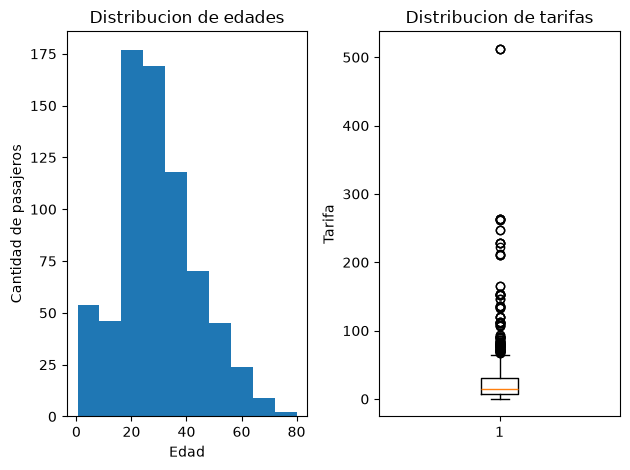

In [90]:
# Ejercicio 15

# creo el espacio para los 2 graficos
# 1 fila y 2 columnas
fig, ax = plt.subplots(1, 2)

# ax[0] es el primer grafico
# dropna saca las edades que estan vacias
# hist hace el histograma
# bins divide las edades en 10 intervalos
ax[0].hist(df["age"].dropna(), bins=10)

# agrego titulo y nombres de los ejes
ax[0].set_title("Distribucion de edades")
ax[0].set_xlabel("Edad")
ax[0].set_ylabel("Cantidad de pasajeros")


# ax[1] es el segundo grafico
# dropna saca las tarifas que estan vacias
# boxplot hace el grafico de caja
ax[1].boxplot(df["fare"].dropna())

# agrego titulo y nombre del eje
ax[1].set_title("Distribucion de tarifas")
ax[1].set_ylabel("Tarifa")


# acomoda los dos graficos para que no se pisen
plt.tight_layout()

# muestra el resultado
plt.show()


# Observaciones:
# la mayor cantidad de pasajeros esta entre los 20 y 40 años
# en las tarifas aparecen algunos valores bastante alejados de la mayoria
# no los elimino porque sean altos, ya que pueden ser datos reales

### Ejercicio 16 — Informe por puerto y exportación

1. Crear una copia de `df` y completar los nulos de `embark_town` con `Sin dato`.
2. Elaborar una tabla por puerto con cantidad de pasajeros, tarifa promedio y porcentaje de supervivencia.
3. Representar el porcentaje de supervivencia por puerto con un gráfico de barras, con eje vertical de 0 a 100.
4. Guardar la tabla en `data/resumen_titanic_por_puerto.csv`, incluyendo el puerto como columna y sin exportar el índice.
5. Volver a leer el archivo y comprobar que conserva las mismas columnas y cantidad de filas.
6. Escribir una conclusión de dos o tres oraciones. Aclarar por qué esta comparación por sí sola no demuestra que el puerto haya causado una diferencia en supervivencia.

**Pista:** usar `.groupby()`, `.agg()`, `.reset_index()` y `.to_csv(index=False)`.

,embark_town,pasajeros,tarifa_promedio,supervivencia
0,Cherbourg,168,59.954144,55.357143
1,Queenstown,77,13.276030,38.961039
2,Sin dato,2,80.000000,100.000000
3,Southampton,644,27.079812,33.695652


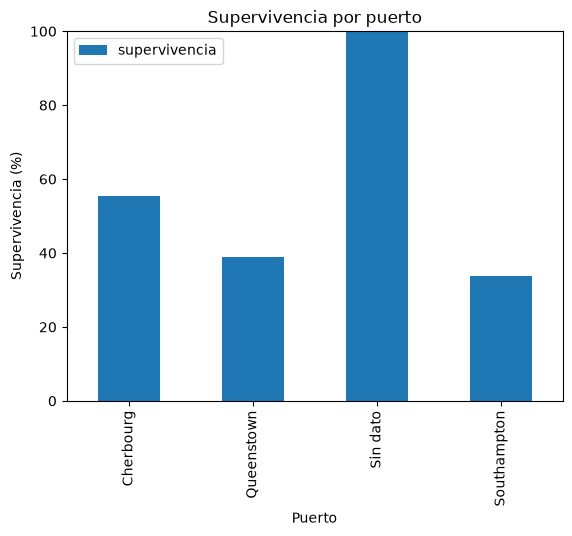

Mismas columnas: True
Misma cantidad de filas: True


In [91]:
# Ejercicio 16

# hago una copia para no modificar el df original
df_puertos = df.copy()

# completo los puertos que estan vacios con "Sin dato"
df_puertos["embark_town"] = df_puertos["embark_town"].fillna("Sin dato")

# agrupo los pasajeros segun el puerto
# count cuenta pasajeros, mean calcula los promedios
tabla = df_puertos.groupby("embark_town").agg(
    pasajeros=("survived", "count"),
    tarifa_promedio=("fare", "mean"),
    supervivencia=("survived", "mean")
)

# convierto la supervivencia a porcentaje
tabla["supervivencia"] = tabla["supervivencia"] * 100

# vuelvo a tener el puerto como una columna normal
tabla = tabla.reset_index()

display(tabla)


# hago el grafico con el porcentaje de supervivencia
tabla.plot(
    x="embark_town",
    y="supervivencia",
    kind="bar",
    ylim=(0, 100)
)

plt.xlabel("Puerto")
plt.ylabel("Supervivencia (%)")
plt.title("Supervivencia por puerto")
plt.show()


# guardo la tabla en un archivo csv
# index=False evita guardar el numero de fila
tabla.to_csv("data/resumen_titanic_por_puerto.csv", index=False)


# vuelvo a leer el archivo que guarde
tabla_leida = pd.read_csv("data/resumen_titanic_por_puerto.csv")

# comparo las columnas y la cantidad de filas
print("Mismas columnas:", list(tabla.columns) == list(tabla_leida.columns))
print("Misma cantidad de filas:", len(tabla) == len(tabla_leida))


# Conclusion:
# se observan distintos porcentajes de supervivencia segun el puerto
# pero esta comparacion sola no demuestra que el puerto sea la causa de la diferencia

# 7. Introducción a la programación orientada a objetos

La programación orientada a objetos permite representar entidades mediante objetos que reúnen **datos** y **comportamientos**.

- **Clase:** definición o modelo a partir del cual se crean objetos.
- **Objeto o instancia:** elemento concreto creado a partir de una clase.
- **Constructor:** método `__init__`, ejecutado al crear el objeto.
- **Atributos:** datos asociados con cada objeto.
- **Métodos:** funciones definidas dentro de una clase.
- **`self`:** referencia al objeto que está ejecutando el método.

En Python, los atributos suelen crearse dentro de `__init__` mediante asignaciones como `self.nombre = nombre`.

### Creación y utilización de un objeto

Al escribir `Agente("Aspiradora")`, Python crea un objeto y ejecuta automáticamente `__init__`. El argumento `"Aspiradora"` se asigna al parámetro `nombre`; `energia` conserva su valor predeterminado.

### Dos objetos de la misma clase

Cada objeto conserva sus propios atributos. Modificar la energía de un agente no modifica la energía del otro.

### Ejercicio 17 — Resuelto

Crear una clase `Sensor` con los atributos `nombre` y `mediciones`. Incorporar métodos para registrar una medición, calcular el promedio y devolver el estado del sensor.

# 8. Ejercicio integrador — Resuelto

A partir de la clase Sensor definida anteriormente, desarrollar un programa que:

- Represente mediante una matriz de NumPy las mediciones realizadas por tres sensores. Cada fila deberá corresponder a un sensor y cada columna, a una medición.
- Recorra las filas de la matriz utilizando range().
- Cree un objeto Sensor por cada fila y registre en él todas sus mediciones.
- Almacene los objetos creados en una lista.
- Recorra la lista de sensores y obtenga, para cada uno, su nombre, su promedio y su estado.

In [92]:
mediciones = np.array([
    [24.0, 25.0, 24.5],
    [31.0, 32.5, 30.0],
    [27.0, 26.5, 28.0]
])

sensores = []



In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Todo funciona")

Todo funciona


## Cierre

En este laboratorio se repasaron estructuras fundamentales de Python y se aplicaron a arrays, tablas y visualizaciones. También se introdujo la programación orientada a objetos mediante clases sencillas que reúnen estado y comportamiento.

### Ideas principales

- Una condición puede evaluar valores *truthy* y *falsy*, pero debe distinguirse `None` de cero cuando el problema lo requiera.
- `range()` genera secuencias enteras y excluye su límite final.
- Una función puede retornar una tupla escribiendo varios valores separados por comas.
- El desempaquetado distribuye los elementos de una secuencia entre variables.
- NumPy permite operar matrices sin recorrer manualmente cada valor.
- Pandas organiza el análisis tabular y Matplotlib permite comunicar los resultados.
- Una clase define atributos y métodos; cada objeto conserva su propio estado.

### Próximamente…

Los conceptos de Python y POO se ampliarán gradualmente a medida que sean necesarios para implementar agentes, estructuras de conocimiento y otros componentes de sistemas de inteligencia artificial.